In [1]:
import keras_ocr
import matplotlib.pyplot as plt
import pandas as pd
from utils import draw_sequence
import cv2
import numpy as np
import os
import string

In [2]:
image_path = "./data/feature1.jpg"
out_dir = "./out"

## 加载模型

In [ ]:
weights_dir = '/Users/ywu/develop/projects/boze/AI/keras-ocr/train/'
# weights_file_name = 'recognizer_borndigital.h5'
weights_file_name = 'recognizer_2025-03-18T17:18:21.883252.h5'

alphabet = string.digits + string.ascii_letters + '+-×±Φφ. '
recognizer_alphabet = ''.join(sorted(set(alphabet)))

# 这里Recognizer使用的alphabet需要和Finetune中的alphabet相同, 不然会报tensor shape mismatch错误
recognizer = keras_ocr.recognition.Recognizer(alphabet=recognizer_alphabet)
weights_path = os.path.join(weights_dir, weights_file_name)
recognizer.model.load_weights(weights_path)
pipeline = keras_ocr.pipeline.Pipeline(recognizer=recognizer)

2025-03-19 09:09:26.387922: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-03-19 09:09:26.387971: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-03-19 09:09:26.387978: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-03-19 09:09:26.388023: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-19 09:09:26.388044: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Provided alphabet does not match pretrained alphabet. Using backbone weights only.
Looking for /Users/ywu/.keras-ocr/crnn_kurapan_notop.h5
Looking for /Users/ywu/.keras-ocr/craft_mlt_25k.h5


## 图片处理

In [4]:
img = cv2.imread(image_path)
sharpening_filter = np.array([[-1,-1,-1],[-1,9,-1],[-1,-1,-1]])
sharpened_image= cv2.filter2D(img,-1,sharpening_filter)

## 检测

In [5]:
results = pipeline.recognize([sharpened_image])
df = pd.DataFrame(results[0],columns=["Text","Bounding_Boxes"])
Bounding_boxes = df["Bounding_Boxes"].values

2025-03-19 09:10:55.679702: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 802ms/step


2025-03-19 09:10:56.806231: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 09:10:57.434443: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 09:10:57.443637: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 09:10:57.619373: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-19 09:10:57.629880: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 2s 394ms/step


## 展示

[(1, ''), (2, ''), (3, ''), (4, ''), (5, ''), (6, ''), (7, ''), (8, ''), (9, ''), (10, ''), (11, ''), (12, ''), (13, ''), (14, ''), (15, ''), (16, ''), (17, ''), (18, ''), (19, ''), (20, ''), (21, ''), (22, ''), (23, ''), (24, ''), (25, ''), (26, ''), (27, ''), (28, ''), (29, ''), (30, ''), (31, ''), (32, ''), (33, ''), (34, ''), (35, ''), (36, ''), (37, ''), (38, ''), (39, ''), (40, ''), (41, ''), (42, ''), (43, ''), (44, ''), (45, ''), (46, ''), (47, '')]


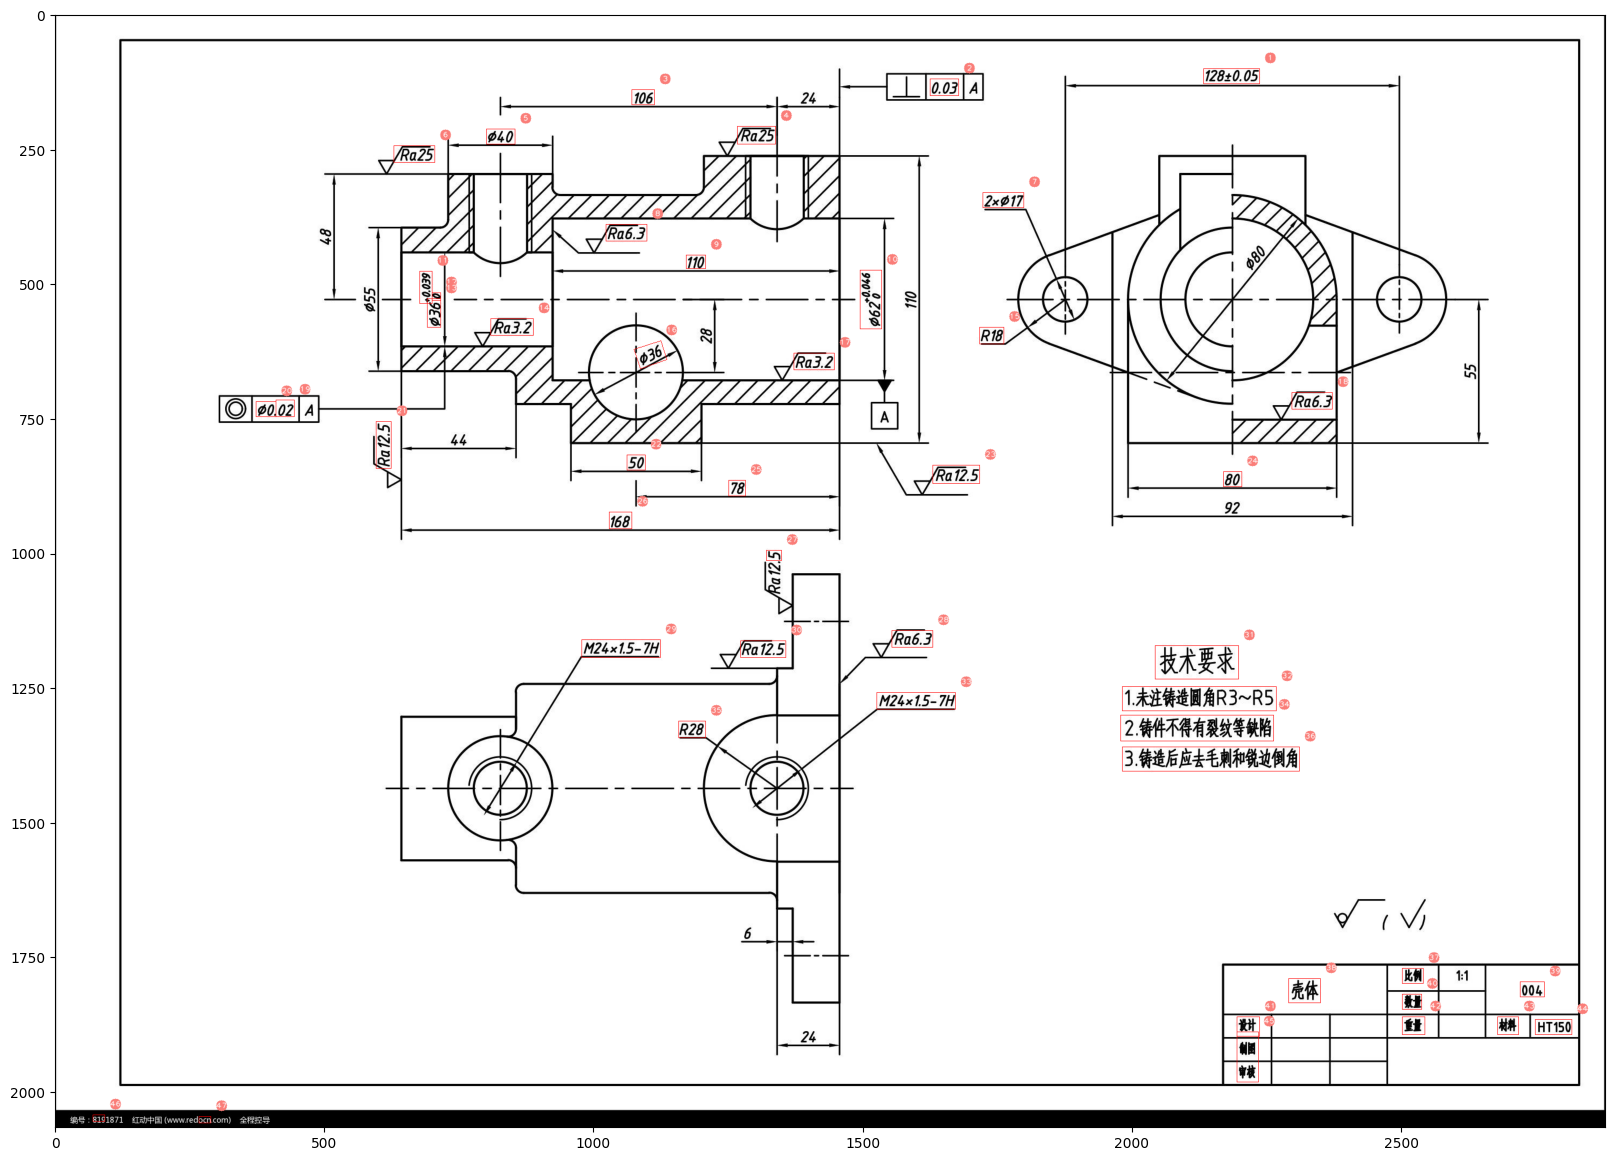

In [6]:
plt.figure(figsize = (20,20))

# 画框
canvas = keras_ocr.tools.drawBoxes(plt.imread(image_path),Bounding_boxes,thickness=1)

# 画标注
Text = df["Text"].values
test_seq = draw_sequence(Text, Bounding_boxes, canvas)

canvas_save = cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB)
cv2.imwrite(f'{out_dir}/feature1_result2.png', canvas_save)

print(test_seq)

plt.imshow(canvas)

# plt.show()